**Author**: Felipe Matheus  
**Surrogate**: annealing — tensile strength (UTS)

Didactic, step-by-step notebook for ONE UTS run (mirrors `annealing_iacs_fixed.ipynb`).
Differences from the IACS notebook, all driven by the UTS data:
- **No essay/schema rows yet** → no `is_essay`, no literature/schema concat; weights are uniform.
- **No held-out validation set yet** (`df_val = None`) → Section 8.1 degrades gracefully.
- **No physical ceiling** like 106 %IACS → only positivity (`Y_MIN = 0`, `Y_MAX = inf`), so truncation is a no-op.
- **5 features** including `initial_diameter` and the recursive `tensile_strength`.

For sweeping many configs use `run_experiments_uts.ipynb`; this one exposes every step.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.modeling.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()

## 1.1 Global configuration

In [3]:
# ---- Experiment settings ----
TAG = "full-features_no-weight"

# ---- Paths ----
FILE_NAME = "dataset_annealing_tensile-strength.csv"
PROCESS = "annealing_uts"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "tensile_strength_final"
FEATURES = ["purity", "initial_diameter", "tensile_strength", "temperature", "time"]
# No essay rows for UTS yet -> uniform weights (kept at 1.0).
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only
NUM_BAG_FOLDS_A = 5              # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0           # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True     # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01       # floor of sigma2_aleat as fraction of Var(y)
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
# No essay rows -> no stratification column; shared folds still available
# (plain KFold, since add_stratified_fold_column falls back when is_essay
# is absent).
USE_SHARED_FOLDS = True
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
# UTS has no fixed ceiling like 106 %IACS. The only hard physical bound is
# positivity, and observed values sit far from 0, so truncation is a no-op.
# Kept explicit for symmetry with the IACS pipeline.
Y_MIN = 0.0
Y_MAX = np.inf

# 2. Data

UTS has a single literature dataset (no schema/essay split yet), so there is no
concat step. Rows missing the target are dropped.

In [4]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME))
df_raw

,material,purity,initial_diameter,grain_size,tensile_strength,temperature,time,grain_size_final,tensile_strength_final,grain_size_ratio,tensile_strength_ratio,is_Cu,yield_strength,yield_strength_final,DOI
0,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,373,60,100.0,1180.0,1.000000,0.983333,True,1140.0,1110.0,10.1016/j.matlet.2004.08.014
1,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,473,60,100.0,1150.0,1.000000,0.958333,True,1140.0,1050.0,10.1016/j.matlet.2004.08.014
2,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,573,60,150.0,850.0,1.500000,0.708333,True,1140.0,640.0,10.1016/j.matlet.2004.08.014
3,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,673,60,250.0,600.0,2.500000,0.500000,True,1140.0,370.0,10.1016/j.matlet.2004.08.014
4,Cu–12 wt% Ag (main data),99.99,23.0,100.0,1200.0,773,60,300.0,330.0,3.000000,0.275000,True,1140.0,200.0,10.1016/j.matlet.2004.08.014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,473,30,7000.0,254.0,1.590909,0.570787,True,442.0,98.0,10.1016/j.jmrt.2023.08.012
88,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,523,30,7800.0,246.0,1.772727,0.552809,True,442.0,92.0,10.1016/j.jmrt.2023.08.012
89,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,573,60,11300.0,244.0,2.568182,0.548315,True,442.0,81.0,10.1016/j.jmrt.2023.08.012
90,Low-oxygen Cu wire Ø3.00 mm drawn from Ø8 mm (...,99.96,3.0,4400.0,445.0,673,60,47200.0,239.0,10.727273,0.537079,True,442.0,64.0,10.1016/j.jmrt.2023.08.012


In [5]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI", "is_Cu"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "tensile_strength",
)

df = (
    df_with_masks[FEATURES + [TARGET]]
    .dropna(subset=[TARGET])
    .reset_index(drop=True)
)

assert df[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df.shape}")
df.head()

Dataset: (92, 6)


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,purity,initial_diameter,tensile_strength,temperature,time,tensile_strength_final
0,99.99,23.0,1200.0,373.0,60.0,1180.0
1,99.99,23.0,1200.0,473.0,60.0,1150.0
2,99.99,23.0,1200.0,573.0,60.0,850.0
3,99.99,23.0,1200.0,673.0,60.0,600.0
4,99.99,23.0,1200.0,773.0,60.0,330.0


## 2.1 Weights & folds

In [6]:
# No essay rows for UTS yet -> uniform weights. weight_col is kept so the
# fit_model_a sample_weight path stays identical to the IACS pipeline.
df["weight_col"] = 1.0

# Optional shared fold column: the SAME partition is passed to AutoGluon
# (groups=) and H2O (fold_column=). add_stratified_fold_column falls back to
# plain KFold automatically when there is no is_essay column to stratify on.
if USE_SHARED_FOLDS:
    df = feng.add_stratified_fold_column(
        df, n_folds=NUM_BAG_FOLDS_A, seed=FOLD_SEED,
    )

df.head()

,purity,initial_diameter,tensile_strength,temperature,time,tensile_strength_final,weight_col,fold_id
0,99.99,23.0,1200.0,373.0,60.0,1180.0,1.0,0
1,99.99,23.0,1200.0,473.0,60.0,1150.0,1.0,4
2,99.99,23.0,1200.0,573.0,60.0,850.0,1.0,4
3,99.99,23.0,1200.0,673.0,60.0,600.0,1.0,2
4,99.99,23.0,1200.0,773.0,60.0,330.0,1.0,0


## 2.2 Validation data

No held-out UTS essays exist yet. When they arrive, load them into `df_val`
(same columns as `df`) and Section 8.1 will report validation metrics
automatically. Until then `df_val = None` and Section 8.1 is skipped.

In [7]:
df_val = None

# 3. Train Model A — Mean Predictor with Bagging

In [8]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    groups="fold_id" if USE_SHARED_FOLDS else None,
    sample_weight="weight_col",
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.73 GB / 31.57 GB (27.7%)
Disk Space Avail:   751.65 GB / 932.08 GB (80.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Values in column 'fold_id' used as split folds instead of being automatically set. Bagged models will have 5 splits.
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_uts\full-features_no-weig

In [9]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# the base learners whose OOF predictions feed the epistemic variance.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-37.892254,root_mean_squared_error,0.105015,23.117259,0.000000,0.007793,2,True,9
1,NeuralNetFastAI_BAG_L1,-42.216257,root_mean_squared_error,0.045997,9.522051,0.045997,9.522051,1,True,6
2,NeuralNetTorch_BAG_L1,-50.998328,root_mean_squared_error,0.036333,12.360613,0.036333,12.360613,1,True,8
3,CatBoost_BAG_L1,-52.976544,root_mean_squared_error,0.013324,53.359118,0.013324,53.359118,1,True,4
4,ExtraTreesMSE_BAG_L1,-54.528618,root_mean_squared_error,0.241064,1.794282,0.241064,1.794282,1,True,5
5,XGBoost_BAG_L1,-63.742202,root_mean_squared_error,0.022686,1.226801,0.022686,1.226801,1,True,7
6,RandomForestMSE_BAG_L1,-65.365728,root_mean_squared_error,0.281823,1.504760,0.281823,1.504760,1,True,3
7,LightGBM_BAG_L1,-82.756278,root_mean_squared_error,0.012699,1.731238,0.012699,1.731238,1,True,2
8,LightGBMXT_BAG_L1,-86.216333,root_mean_squared_error,0.023408,1.435225,0.023408,1.435225,1,True,1


## 3.1 H2O AutoML Comparison

In [10]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET, "weight_col"]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
                    weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpd33i9ihb
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpd33i9ihb\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpd33i9ihb\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,3 months and 13 days
H2O_cluster_name:,H2O_from_python_fmfoa_r68v1u
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
11:43:50.922: Fold column fold_id will be used for cross-validation. nfolds parameter will be ignored.
11:43:50.929: AutoML: XGBoost is not available; skipping it.


11:43:51.338: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 92.0.

██
11:43:52.471: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.
11:43:52.603: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

█████
11:43:53.181: _weights_column param, All base models use weight

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260625_114350_model_731,37.6518,1417.66,21.5864,0.094186,1417.66
StackedEnsemble_BestOfFamily_5_AutoML_1_20260625_114350,39.9146,1593.18,22.7043,0.100918,1593.18
StackedEnsemble_BestOfFamily_3_AutoML_1_20260625_114350,40.3621,1629.1,22.9273,0.102192,1629.1
GBM_grid_1_AutoML_1_20260625_114350_model_1349,43.1187,1859.22,21.6016,0.102014,1859.22
GBM_grid_1_AutoML_1_20260625_114350_model_703,43.8278,1920.88,21.2225,0.101106,1920.88
GBM_grid_1_AutoML_1_20260625_114350_model_81,45.7061,2089.05,22.3128,0.105163,2089.05
GBM_grid_1_AutoML_1_20260625_114350_model_151,45.9093,2107.67,26.1421,0.110123,2107.67
GBM_grid_1_AutoML_1_20260625_114350_model_55,46.0285,2118.62,24.3033,0.10631,2118.62
GBM_grid_1_AutoML_1_20260625_114350_model_166,46.9039,2199.98,21.2442,0.0981122,2199.98
GBM_grid_1_AutoML_1_20260625_114350_model_171,47.4338,2249.97,24.4439,0.109275,2249.97


In [11]:
# The coherent OOF-vs-OOF comparison (unweighted metrics, same folds) is in
# Section 10. AutoGluon's score_val vs H2O's weighted xval RMSE would be
# apples-to-oranges, so it is intentionally not used here.
print("See Section 10 for the coherent OOF-vs-OOF comparison.")

See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

In [12]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(92,)  any NaN? False


## 4.1 Fast check on big residuals

In [13]:
residuals_oof.describe()

count     92.000000
mean       1.728334
std       38.060231
min     -182.775513
25%      -15.013811
50%        0.699899
75%       17.890004
max      131.179504
Name: tensile_strength_final, dtype: float64

In [14]:
# Rows where the ensemble is off by a large UTS margin (units: MPa).
df[residuals_oof.abs() > 50]

,purity,initial_diameter,tensile_strength,temperature,time,tensile_strength_final,weight_col,fold_id
0,99.99,23.0,1200.0,373.0,60.0,1180.0,1.0,0
1,99.99,23.0,1200.0,473.0,60.0,1150.0,1.0,4
4,99.99,23.0,1200.0,773.0,60.0,330.0,1.0,0
5,99.99,20.0,900.0,573.0,60.0,700.0,1.0,1
7,99.99,20.0,1100.0,573.0,60.0,800.0,1.0,2
8,99.99,20.0,1100.0,673.0,60.0,600.0,1.0,2
84,99.96,3.0,445.0,423.0,30.0,433.0,1.0,3
86,99.96,3.0,445.0,453.0,30.0,289.0,1.0,2


## 4.2 Recovering weights

In [15]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (8, 92)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1']


In [16]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000032  (OK)

Non-zero weights:
  NeuralNetFastAI_BAG_L1          0.5263
  XGBoost_BAG_L1                  0.1579
  NeuralNetTorch_BAG_L1           0.3158


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

In [17]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()

count    9.200000e+01
mean     6.922207e-06
std      5.632096e-06
min      1.709501e-07
25%      3.138913e-06
50%      5.379352e-06
75%      9.561561e-06
max      3.183739e-05
Name: tensile_strength_final, dtype: float64

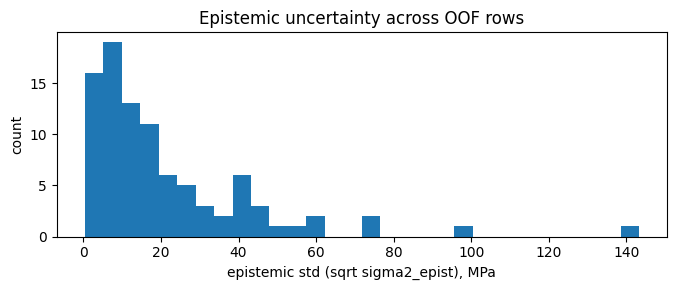

In [18]:
plt.figure(figsize=(7, 3))
plt.hist(np.sqrt(sigma2_epist_oof), bins=30)
plt.xlabel("epistemic std (sqrt sigma2_epist), MPa")
plt.ylabel("count")
plt.title("Epistemic uncertainty across OOF rows")
plt.tight_layout()
plt.show()

# 6. Build Aleatoric Targets $\tilde r^2$

In [19]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 92
  n_truncated          = 39
  pct_truncated        = 42.391304347826086
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 31509.406862930064
  r_tilde_sq_mean      = 920.1916997284562
  r_tilde_sq_median    = 28.77105223695363


# 7. Train Model B — Aleatoric Variance Predictor

In [20]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.08 GB / 31.57 GB (19.3%)
Disk Space Avail:   751.46 GB / 932.08 GB (80.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_uts\full-features_no-weight\model_b"
Train Data Rows:    92
Train Data Columns: 5
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (10.358041410833437, -13.815510557964274, -2.6156

In [21]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-9.571765,root_mean_squared_error,0.053740,10.814674,0.000000,0.009013,2,True,10
1,NeuralNetFastAI_BAG_L1,-9.711019,root_mean_squared_error,0.036841,8.556530,0.036841,8.556530,1,True,6
2,XGBoost_BAG_L1,-9.725513,root_mean_squared_error,0.014509,0.818743,0.014509,0.818743,1,True,7
3,NeuralNetTorch_BAG_L1,-9.776993,root_mean_squared_error,0.035748,7.346092,0.035748,7.346092,1,True,8
4,CatBoost_BAG_L1,-9.795386,root_mean_squared_error,0.007014,2.204056,0.007014,2.204056,1,True,4
5,LightGBMLarge_BAG_L1,-9.811639,root_mean_squared_error,0.002389,1.430388,0.002389,1.430388,1,True,9
6,LightGBMXT_BAG_L1,-9.900837,root_mean_squared_error,0.006520,1.872735,0.006520,1.872735,1,True,1
7,LightGBM_BAG_L1,-9.913798,root_mean_squared_error,0.003008,1.792592,0.003008,1.792592,1,True,2
8,ExtraTreesMSE_BAG_L1,-10.947830,root_mean_squared_error,0.073666,0.503963,0.073666,0.503963,1,True,5
9,RandomForestMSE_BAG_L1,-11.066288,root_mean_squared_error,0.045854,0.598049,0.045854,0.598049,1,True,3


# 8. Calibration Diagnostics

In [22]:
df[TARGET].var()

np.float64(36431.93333186814)

In [23]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.510870,0.010870
1,0.80,0.804348,0.004348
2,0.90,0.902174,0.002174
3,0.95,0.945652,-0.004348


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference.

In [24]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.0271

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.532609,0.032609
1,0.80,0.815217,0.015217
2,0.90,0.913043,0.013043
3,0.95,0.945652,-0.004348


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with recalibration $c$) on a held-out
`df_val`. UTS has none yet, so this section is guarded by `if df_val is not None`.
The moment essays arrive, set `df_val` in Section 2.2 and these cells report
validation rmse/mae/coverage with no other change. `modl.predict_target` is
target-agnostic (DataFrame or dict, any AutoGluon predictor).

In [25]:
if df_val is not None:
    preds_val = modl.predict_with_uncertainty(
        X=df_val,
        predictor_a=predictor_a,
        predictor_b=predictor_b,
        weights=weights,
        model_names=base_model_names,
        features=FEATURES,
        variance_floor=variance_floor,
        recalibration_c=c_opt,
        use_weights=USE_WEIGHTED_VARIANCE,
        y_min=Y_MIN,
        y_max=Y_MAX,
    )
    val_metrics = evla.metrics_on_dataframe(
        df=df_val,
        target=TARGET,
        mu=preds_val["mu"].to_numpy(),
        sigma=preds_val["sigma_total"].to_numpy(),
        alphas=CALIBRATION_ALPHAS,
    )
    print("=== Validation metrics ===")
    print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
    print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})
else:
    print("No df_val yet for UTS - skipping validation metrics.")
    val_metrics = None

No df_val yet for UTS - skipping validation metrics.


In [26]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {"purity": 99.99, "initial_diameter": 23.0, "tensile_strength": 1200.0,
     "temperature": 473.0, "time": 60.0},
)
print(f"Predicted {TARGET}: {single[0]:.1f} MPa")

Predicted tensile_strength_final: 1011.9 MPa


# 9. Inference Example

Full predictive output with every mechanism on: epistemic + aleatoric variance,
OOD inflation, recalibration. Truncation columns (`mu_trunc`, `sigma_trunc`,
`p_above_max`) only appear when `Y_MAX`/`Y_MIN` are finite; for UTS `Y_MAX=inf`,
so the truncation block is a no-op and those columns are omitted.

In [27]:
df.head(5)

,purity,initial_diameter,tensile_strength,temperature,time,tensile_strength_final,weight_col,fold_id
0,99.99,23.0,1200.0,373.0,60.0,1180.0,1.0,0
1,99.99,23.0,1200.0,473.0,60.0,1150.0,1.0,4
2,99.99,23.0,1200.0,573.0,60.0,850.0,1.0,4
3,99.99,23.0,1200.0,673.0,60.0,600.0,1.0,2
4,99.99,23.0,1200.0,773.0,60.0,330.0,1.0,0


In [28]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_min=Y_MIN,
    y_max=Y_MAX,          # inf -> no truncation columns for UTS
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,1114.078783,1336.307395,364.319333,1793.999528,42.355632,1114.078735,1.000000,1114.078783,42.355632,0.0
1,1011.851380,1626.951372,364.319333,2100.601294,45.832317,1011.851379,1.000000,1011.851380,45.832317,0.0
2,812.857737,1712.105876,364.319333,2190.431200,46.802043,812.857727,1.000000,812.857737,46.802043,0.0
3,591.804898,601.037210,364.319333,1018.359381,31.911744,591.804871,1.000000,591.804898,31.911744,0.0
4,443.928959,1035.860580,364.319333,1477.056700,38.432495,443.928955,1.003023,443.928959,38.432495,0.0


# 10. Persist Artifacts

In [29]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_min": Y_MIN,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")

Saved to: ../../models/annealing_uts\full-features_no-weight\artifacts.pkl


In [30]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MIN": Y_MIN,
    "Y_MAX": str(Y_MAX),  # inf is not native-YAML; store as string
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")

Saved to: ../../models/annealing_uts\full-features_no-weight\global_config.txt


In [31]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")

                         model       rmse        mae      mape        r2
0  AutoGluon (Model A, leader)  37.892254  25.190660  8.033440  0.960156
1          H2O AutoML (leader)  37.651836  21.586424  6.256765  0.960660
Saved to: ../../models/annealing_uts\full-features_no-weight


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

Loads ONLY what was persisted in Section 10 (`artifacts.pkl`) plus the two
predictors from disk — no in-session variable reused. This is what a deployment
script / the MBC controller would do.

In [32]:
# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_min', 'y_max', 'ood_ref']
Target: tensile_strength_final
Features: ['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time']


In [33]:
# ---- 3) Predict using ONLY the reloaded objects ----
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_min=loaded_artifacts["y_min"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,1114.078783,1336.307395,364.319333,1793.999528,42.355632,1114.078735,1.000000,1114.078783,42.355632,0.0
1,1011.851380,1626.951372,364.319333,2100.601294,45.832317,1011.851379,1.000000,1011.851380,45.832317,0.0
2,812.857737,1712.105876,364.319333,2190.431200,46.802043,812.857727,1.000000,812.857737,46.802043,0.0
3,591.804898,601.037210,364.319333,1018.359381,31.911744,591.804871,1.000000,591.804898,31.911744,0.0
4,443.928959,1035.860580,364.319333,1477.056700,38.432495,443.928955,1.003023,443.928959,38.432495,0.0


In [34]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {"purity": 99.99, "initial_diameter": 23.0, "tensile_strength": 1200.0,
     "temperature": 473.0, "time": 60.0},
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.1f} MPa")

Predicted tensile_strength_final: 1011.9 MPa


In [35]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
